# BERT Pilot - Subamostragem Rapida por Fonte

## Objetivo
Fazer um piloto rapido, antes de gerar mais contrafactuais, para testar se a hipotese principal melhora quando reduzimos o desequilibrio por fonte mantendo os 100+100 ja criados no dataset 5700.

### Subamostragem pedida
- `biased-corpus`: 233 biased + 100 neutral
- `gemini` (equivale ao `local`/Gemini nas versoes anteriores): 100 biased + 233 neutral
- `gus-dataset-v1`: como esta

### O notebook faz
1. Carrega `bias_sentences_mixed_5700.json` e `feature_matrix_bert_mixed_5700.pkl`
2. Cria o subset piloto e guarda copias em `dataset/v2/`
3. Corre LOSO por fonte com a mesma familia de pipeline usada antes
4. Treina um classificador de fonte para medir quanto sinal de dominio ainda existe


In [1]:
import json
import os
import warnings
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

cwd = Path.cwd().resolve()
root_dir = cwd
while root_dir.name != 'attention-atlas' and root_dir.parent != root_dir:
    root_dir = root_dir.parent

if root_dir.name != 'attention-atlas':
    raise RuntimeError('Nao foi possivel localizar a raiz do repositorio attention-atlas.')

pilot_dir = root_dir / 'dataset' / 'v2'
pilot_dir.mkdir(parents=True, exist_ok=True)

dataset_path = root_dir / 'dataset' / 'bias_sentences_mixed_5700.json'
features_path = root_dir / 'attention_app' / 'bias' / 'extracted_features' / 'feature_matrix_bert_mixed_5700.pkl'
pilot_json_path = pilot_dir / 'bias_sentences_mixed_pilot_1373.json'
pilot_pkl_path = pilot_dir / 'feature_matrix_bert_mixed_pilot_1373.pkl'

print(f'root_dir: {root_dir}')
print(f'dataset_path: {dataset_path}')
print(f'features_path: {features_path}')


root_dir: C:\Users\anoca\Documents\GitHub\attention-atlas
dataset_path: C:\Users\anoca\Documents\GitHub\attention-atlas\dataset\bias_sentences_mixed_5700.json
features_path: C:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\extracted_features\feature_matrix_bert_mixed_5700.pkl


## 1. Carregar dataset 5700 e features
O dataset 5700 ja contem os contrafactuais 100+100, por isso esta celula usa esse ficheiro como base para o piloto.


In [2]:
with open(dataset_path, 'r', encoding='utf-8') as f:
    data_5700 = json.load(f)

df_full = pd.DataFrame(data_5700['entries']).copy()
df_full['label'] = df_full['has_bias'].astype(int)
df_full['orig_index'] = np.arange(len(df_full))

df_features_full = pd.read_pickle(features_path).copy()

if len(df_full) != len(df_features_full):
    raise RuntimeError(
        f'Incompatibilidade: dataset tem {len(df_full)} linhas e o pkl tem {len(df_features_full)}.'
    )

print(f'Dataset base: {len(df_full)} entradas')
print(f'Features base: {df_features_full.shape[0]} x {df_features_full.shape[1]}')
print()
ct_full = pd.crosstab(df_full['source'], df_full['label'], margins=True)
ct_full = ct_full.rename(columns={0: 'neutral', 1: 'biased'})
ct_full.index.name = 'source'
ct_full


Dataset base: 5700 entradas
Features base: 5700 x 3239



label,neutral,biased,All
source,,,
biased-corpus,100,2476,2576
gemini,2317,100,2417
gus-dataset-v1,433,274,707
All,2850,2850,5700


## 2. Criar o subset piloto
A amostragem e estratificada manualmente por fonte e classe, sempre com `random_state=42`. O GUS fica completo.


In [3]:
sampling_plan = {
    ('biased-corpus', 1): 233,
    ('biased-corpus', 0): 100,
    ('gemini', 1): 100,
    ('gemini', 0): 233,
    ('gus-dataset-v1', 1): None,
    ('gus-dataset-v1', 0): None,
}

selected_parts = []
summary_rows = []

for (source_name, label_value), target_n in sampling_plan.items():
    block = df_full[(df_full['source'] == source_name) & (df_full['label'] == label_value)].copy()
    available_n = len(block)

    if target_n is None:
        picked = block.copy()
        target_n = available_n
    else:
        if available_n < target_n:
            raise ValueError(
                f'A fonte {source_name} / label={label_value} so tem {available_n} exemplos, mas foram pedidos {target_n}.'
            )
        picked = block.sample(n=target_n, random_state=RANDOM_STATE)

    selected_parts.append(picked)
    summary_rows.append({
        'source': source_name,
        'label': label_value,
        'available': available_n,
        'selected': len(picked),
    })

df_sampling = pd.DataFrame(summary_rows).sort_values(['source', 'label']).reset_index(drop=True)
df_sampling['class_name'] = df_sampling['label'].map({0: 'neutral', 1: 'biased'})
display(df_sampling[['source', 'class_name', 'available', 'selected']])

df_pilot = pd.concat(selected_parts, ignore_index=True)
df_pilot = df_pilot.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df_pilot['id'] = np.arange(1, len(df_pilot) + 1)

df_features_pilot = df_features_full.iloc[df_pilot['orig_index'].to_numpy()].reset_index(drop=True).copy()

print(f'Total piloto: {len(df_pilot)} entradas')
ct_pilot = pd.crosstab(df_pilot['source'], df_pilot['label'], margins=True)
ct_pilot = ct_pilot.rename(columns={0: 'neutral', 1: 'biased'})
ct_pilot.index.name = 'source'
ct_pilot


,source,class_name,available,selected
0,biased-corpus,neutral,100,100
1,biased-corpus,biased,2476,233
2,gemini,neutral,2317,233
3,gemini,biased,100,100
4,gus-dataset-v1,neutral,433,433
5,gus-dataset-v1,biased,274,274


Total piloto: 1373 entradas


label,neutral,biased,All
source,,,
biased-corpus,100,233,333
gemini,233,100,333
gus-dataset-v1,433,274,707
All,766,607,1373


In [4]:
pilot_entries = df_pilot.drop(columns=['label', 'orig_index']).to_dict(orient='records')
with open(pilot_json_path, 'w', encoding='utf-8') as f:
    json.dump({'entries': pilot_entries}, f, indent=2, ensure_ascii=False)

df_features_pilot.to_pickle(pilot_pkl_path)

print(f'JSON guardado em: {pilot_json_path}')
print(f'PKL guardado em:  {pilot_pkl_path}')


JSON guardado em: C:\Users\anoca\Documents\GitHub\attention-atlas\dataset\v2\bias_sentences_mixed_pilot_1373.json
PKL guardado em:  C:\Users\anoca\Documents\GitHub\attention-atlas\dataset\v2\feature_matrix_bert_mixed_pilot_1373.pkl


## 3. Preparar os dados para modelacao
Mantemos a mesma ideia dos notebooks anteriores: `VarianceThreshold -> StandardScaler -> XGBoost`, com grupos por texto para evitar leakage.


In [5]:
drop_cols = ['label', 'id', 'text', 'source', 'original_id']
X = df_features_pilot.drop(columns=[c for c in drop_cols if c in df_features_pilot.columns]).copy()
y = df_features_pilot['label'].copy()
sources = df_pilot['source'].to_numpy()
texts = df_pilot['text'].astype(str)

text_to_group = {text: idx for idx, text in enumerate(texts.unique())}
groups = texts.map(text_to_group).to_numpy()

print(f'Amostras: {len(X)}')
print(f'Features: {X.shape[1]}')
print(f'Grupos unicos: {len(text_to_group)}')
print(f'Sources: {pd.Series(sources).value_counts().to_dict()}')
print(f'Labels: {y.value_counts().sort_index().to_dict()}')

def build_xgb_pipeline():
    return Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(
            tree_method='approx',
            max_depth=8,
            n_estimators=500,
            learning_rate=0.05,
            min_child_weight=1,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            verbosity=0,
        )),
    ])


Amostras: 1373
Features: 3238
Grupos unicos: 1373
Sources: {'gus-dataset-v1': 707, 'gemini': 333, 'biased-corpus': 333}
Labels: {0: 766, 1: 607}


## 4. LOSO por fonte no subset piloto
Como agora cada fonte tem ambas as classes, todas as folds held-out passam a ter AUC e F1 interpretaveis.


In [6]:
unique_sources = np.sort(np.unique(sources))
loso_results = []

for test_source in unique_sources:
    test_mask = sources == test_source
    train_mask = ~test_mask

    X_train = X.iloc[np.where(train_mask)[0]]
    X_test = X.iloc[np.where(test_mask)[0]]
    y_train = y.iloc[np.where(train_mask)[0]]
    y_test = y.iloc[np.where(test_mask)[0]]
    groups_train = groups[train_mask]

    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    pipe = build_xgb_pipeline()

    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        n_jobs=1,
    )

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    result = {
        'test_source': test_source,
        'n_test': len(y_test),
        'test_biased': int(y_test.sum()),
        'test_neutral': int((1 - y_test).sum()),
        'cv_auc': cv_scores['test_roc_auc'].mean(),
        'cv_f1': cv_scores['test_f1'].mean(),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_prob),
        'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
    }
    loso_results.append(result)

    print(f'Test source: {test_source}')
    print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
    print(f'Test biased={int(y_test.sum())} | neutral={int((1 - y_test).sum())}')
    print(f"Internal CV -> AUC={result['cv_auc']:.4f} | F1={result['cv_f1']:.4f}")
    print(f"Held-out  -> AUC={result['auc']:.4f} | Acc={result['accuracy']:.4f} | F1={result['f1']:.4f}")
    print('Confusion matrix:')
    print(np.array(result['confusion_matrix']))
    print()

df_loso = pd.DataFrame(loso_results)
df_loso[['test_source', 'n_test', 'test_biased', 'test_neutral', 'cv_auc', 'cv_f1', 'accuracy', 'precision', 'recall', 'f1', 'auc']]


Test source: biased-corpus
Train size: 1040 | Test size: 333
Test biased=233 | neutral=100
Internal CV -> AUC=0.8737 | F1=0.6971
Held-out  -> AUC=0.7679 | Acc=0.7117 | F1=0.7788
Confusion matrix:
[[ 68  32]
 [ 64 169]]

Test source: gemini
Train size: 1040 | Test size: 333
Test biased=100 | neutral=233
Internal CV -> AUC=0.8775 | F1=0.7827
Held-out  -> AUC=0.7719 | Acc=0.7387 | F1=0.5991
Confusion matrix:
[[181  52]
 [ 35  65]]

Test source: gus-dataset-v1
Train size: 666 | Test size: 707
Test biased=274 | neutral=433
Internal CV -> AUC=0.9544 | F1=0.8701
Held-out  -> AUC=0.5278 | Acc=0.3734 | F1=0.5322
Confusion matrix:
[[ 12 421]
 [ 22 252]]



,test_source,n_test,test_biased,test_neutral,cv_auc,cv_f1,accuracy,precision,recall,f1,auc
0,biased-corpus,333,233,100,0.873696,0.697092,0.711712,0.840796,0.725322,0.778802,0.767854
1,gemini,333,100,233,0.877516,0.782695,0.738739,0.555556,0.650000,0.599078,0.771888
2,gus-dataset-v1,707,274,433,0.954421,0.870058,0.373409,0.374443,0.919708,0.532207,0.527764


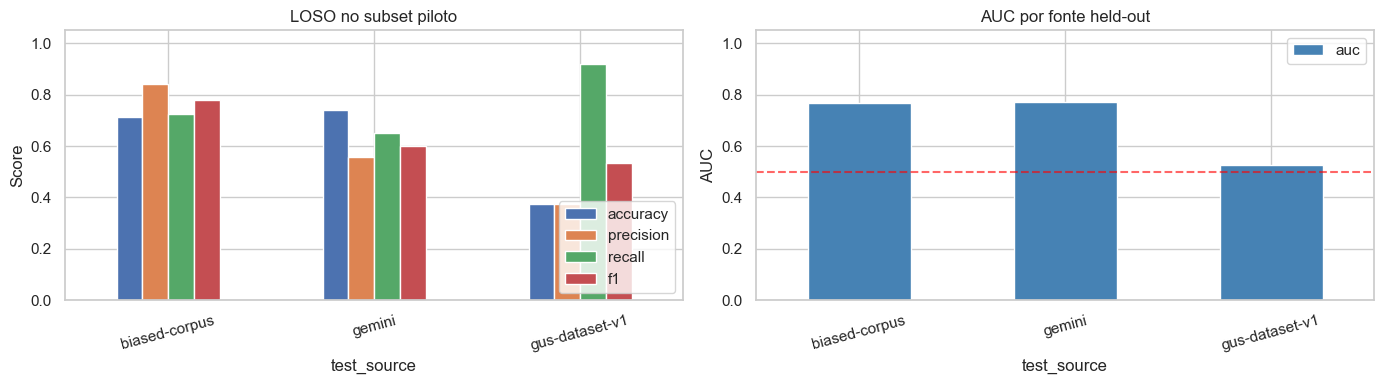

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_cols = ['accuracy', 'precision', 'recall', 'f1']
df_loso.set_index('test_source')[plot_cols].plot(kind='bar', ax=axes[0], rot=15)
axes[0].set_title('LOSO no subset piloto')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')

df_loso.set_index('test_source')[['auc']].plot(kind='bar', ax=axes[1], rot=15, color='steelblue')
axes[1].set_title('AUC por fonte held-out')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0, 1.05)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 5. Classificador de fonte
Se a accuracy continuar muito acima de 33.3%, as features ainda codificam origem/dominio de forma forte mesmo depois da subamostragem.


Classes: ['biased-corpus', 'gemini', 'gus-dataset-v1']
Random baseline: 0.3333
CV accuracy: 0.7386 +/- 0.0273
Test accuracy: 0.7471

                precision    recall  f1-score   support

 biased-corpus       0.63      0.55      0.59        95
        gemini       0.77      0.81      0.79        83
gus-dataset-v1       0.79      0.83      0.81       166

      accuracy                           0.75       344
     macro avg       0.73      0.73      0.73       344
  weighted avg       0.74      0.75      0.74       344



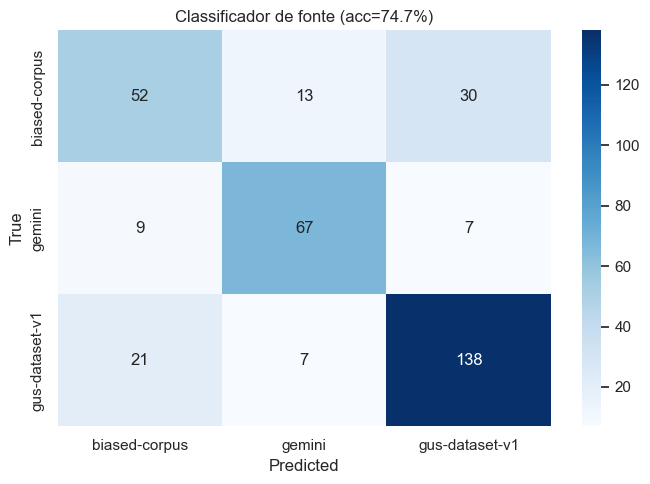

In [8]:
le = LabelEncoder()
y_source = le.fit_transform(sources)
random_baseline = 1 / len(le.classes_)

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y_source, groups=groups))

X_train_src = X.iloc[train_idx]
X_test_src = X.iloc[test_idx]
y_train_src = y_source[train_idx]
y_test_src = y_source[test_idx]
groups_train_src = groups[train_idx]

src_pipe = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, multi_class='multinomial')),
] )

cv_src = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
src_scores = cross_validate(
    src_pipe,
    X_train_src,
    y_train_src,
    cv=cv_src,
    groups=groups_train_src,
    scoring='accuracy',
    n_jobs=1,
)

src_pipe.fit(X_train_src, y_train_src)
y_pred_src = src_pipe.predict(X_test_src)
acc_src = accuracy_score(y_test_src, y_pred_src)
cm_src = confusion_matrix(y_test_src, y_pred_src)

print(f'Classes: {list(le.classes_)}')
print(f'Random baseline: {random_baseline:.4f}')
print(f"CV accuracy: {src_scores['test_score'].mean():.4f} +/- {src_scores['test_score'].std():.4f}")
print(f'Test accuracy: {acc_src:.4f}')
print()
print(classification_report(y_test_src, y_pred_src, target_names=le.classes_, zero_division=0))

plt.figure(figsize=(7, 5))
sns.heatmap(cm_src, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Classificador de fonte (acc={acc_src:.1%})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


### 1. Houve melhoria clara em `biased-corpus` e `gemini`
No diagnóstico anterior, quando estas fontes ficavam em held-out, o desempenho colapsava quase por completo.  
Com a subamostragem atual:
- **`biased-corpus`**: `AUC=0.7679`, `Acc=0.7117`, `F1=0.7788`
- **`gemini`**: `AUC=0.7719`, `Acc=0.7387`, `F1=0.5991`
Isto mostra que, depois de quebrar parcialmente a associação quase perfeita entre fonte e classe, o modelo já consegue generalizar **muito melhor** para estas duas fontes.  
Ou seja, a hipótese de que o modelo estava a explorar **atalhos de domínio/fonte** fica **fortemente reforçada**.
### 2. O problema não desapareceu: `gus-dataset-v1` continua difícil
Para `gus-dataset-v1`, o desempenho continua fraco:
- **`AUC=0.5278`**
- **`Acc=0.3734`**
- **`F1=0.5322`**
A matriz de confusão mostra que o modelo prevê quase tudo como **biased**:
- muitos **falsos positivos** no lado neutral (`421`)
- recall alto para biased, mas à custa de quase não reconhecer exemplos neutros
Isto sugere que o GUS continua a funcionar como um **domínio realmente diferente**, e que o modelo ainda não aprendeu uma representação robusta o suficiente para separar bias de neutralidade neste tipo de texto.
### 3. O contraste entre CV interna e teste held-out continua a ser importante
Nas três folds, a **CV interna** é bastante superior ao desempenho no teste held-out, especialmente em `gus-dataset-v1`:
- `biased-corpus`: CV AUC `0.8737` -> held-out AUC `0.7679`
- `gemini`: CV AUC `0.8775` -> held-out AUC `0.7719`
- `gus-dataset-v1`: CV AUC `0.9544` -> held-out AUC `0.5278`
Isto indica que, mesmo com este piloto, o modelo ainda retém algum grau de **dependência do domínio de treino**.  
Portanto, a mitigação ajudou, mas **não resolveu totalmente** o problema.
### 4. Leitura global
Em termos práticos, este piloto sugere:
- a hipótese principal está **validada de forma preliminar**;
- o colapso anterior em `biased-corpus` e `gemini` era em grande parte explicado pelo desequilíbrio fonte-classe;
- no entanto, **a robustez cross-source ainda é limitada**, sobretudo para GUS;
- por isso, faz sentido avançar para uma próxima fase de mitigação mais forte, em vez de assumir já que o problema está resolvido.
### 5. Implicação para o próximo passo
Antes de escalar para mais geração, estes resultados justificam:
1. **continuar a introduzir contrafactuais / balanceamento por fonte**, sobretudo onde ainda há assimetria estilística;
2. **dar atenção especial ao GUS**, porque parece trazer um tipo de variação linguística/conceptual que o modelo ainda não absorveu;
3. comparar este piloto com o dataset anterior para mostrar, de forma explícita, que houve **melhoria real no LOSO** após a mitigação.
### Conclusão final
O piloto apoia a ideia de que o classificador não estava apenas a aprender “bias”, mas também **marcadores de origem/domínio**.  
Depois da subamostragem, o modelo melhora substancialmente em `biased-corpus` e `gemini`, o que é um bom sinal.  
No entanto, como `gus-dataset-v1` continua perto do aleatório em AUC, a evidência aponta para uma conclusão mais equilibrada: **o confounding diminuiu, mas ainda não foi eliminado**.